In [1]:
import whisper
print(whisper.__version__)

20250625


In [4]:
import pyttsx3
import whisper
print("pyttsx3 ready")
print("whisper ready")

# Test whisper loads base model
model = whisper.load_model("base")
print(f"Whisper base model loaded: {model}")

pyttsx3 ready
whisper ready
Whisper base model loaded: Whisper(
  (encoder): AudioEncoder(
    (conv1): Conv1d(80, 512, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(512, 512, kernel_size=(3,), stride=(2,), padding=(1,))
    (blocks): ModuleList(
      (0-5): 6 x ResidualAttentionBlock(
        (attn): MultiHeadAttention(
          (query): Linear(in_features=512, out_features=512, bias=True)
          (key): Linear(in_features=512, out_features=512, bias=False)
          (value): Linear(in_features=512, out_features=512, bias=True)
          (out): Linear(in_features=512, out_features=512, bias=True)
        )
        (attn_ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
        (mlp_ln): LayerNorm((512,), eps=1e-05, elementwise_affi

In [6]:
import pyttsx3
import whisper
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import re
from pathlib import Path

FAQ_PATH   = r"E:\Rohanta_AI_workbook\campus_chatbot\data\faq.csv"
AUDIO_DIR  = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\data\audio_samples")
AUDIO_DIR.mkdir(parents=True, exist_ok=True)

df_faq = pd.read_csv(FAQ_PATH)

# Check actual columns
print(f"Columns: {df_faq.columns.tolist()}")
print(f"Total rows: {len(df_faq)}")
print(f"Intent distribution:\n{df_faq['intent'].value_counts()}")

# Sample 17 from each intent
df_sample = pd.concat([
    df_faq[df_faq["intent"] == intent].sample(min(17, len(df_faq[df_faq["intent"] == intent])), random_state=42)
    for intent in df_faq["intent"].unique()
]).reset_index(drop=True)

print(f"\nTotal samples selected : {len(df_sample)}")
print(f"Intent distribution:\n{df_sample['intent'].value_counts()}")

Columns: ['query', 'intent', 'entity']
Total rows: 734
Intent distribution:
intent
find_location    517
ask_hours        184
find_event        33
Name: count, dtype: int64

Total samples selected : 51
Intent distribution:
intent
find_location    17
ask_hours        17
find_event       17
Name: count, dtype: int64


In [8]:
from gtts import gTTS

def generate_audio(text: str, output_path: str) -> bool:
    try:
        tts = gTTS(text=text, lang="en", slow=False)
        tts.save(output_path)
        return True
    except Exception as e:
        print(f"TTS error: {e}")
        return False


# Generate audio for all samples
print("Generating audio files...")
audio_paths = []

for i, row in df_sample.iterrows():
    audio_path = str(AUDIO_DIR / f"sample_{i:04d}.wav")
    success    = generate_audio(row["query"], audio_path)
    audio_paths.append(audio_path if success else None)

    if (len(audio_paths)) % 10 == 0:
        print(f"  Generated {len(audio_paths)}/{len(df_sample)}")

df_sample["audio_path"] = audio_paths
print(f"\nDone. Audio files saved to {AUDIO_DIR}")
print(f"Successful: {sum(1 for p in audio_paths if p)}/{len(audio_paths)}")

Generating audio files...
  Generated 10/51
  Generated 20/51
  Generated 30/51
  Generated 40/51
  Generated 50/51

Done. Audio files saved to E:\Rohanta_AI_workbook\campus_chatbot\data\audio_samples
Successful: 51/51


In [9]:
import os

# Check first few audio files exist and have size
for i, row in df_sample.head(3).iterrows():
    path = row["audio_path"]
    if path and os.path.exists(path):
        size = os.path.getsize(path)
        print(f"OK   : {os.path.basename(path)} — {size} bytes")
        print(f"Text : {row['query']}")
    else:
        print(f"MISSING: {path}")
    print()

OK   : sample_0000.wav — 45504 bytes
Text : Where is Digital Electronics Lab (ENTC-L502)?

OK   : sample_0001.wav — 30720 bytes
Text : What floor is CVL-C701 on?

OK   : sample_0002.wav — 27840 bytes
Text : What floor is IT-C305 on?



In [10]:
whisper_model = whisper.load_model("base")
print("Whisper base model ready")

def transcribe_audio(audio_path: str) -> dict:
    try:
        t0     = time.time()
        result = whisper_model.transcribe(audio_path, language="en")
        elapsed = (time.time() - t0) * 1000
        return {
            "transcript": result["text"].strip(),
            "time_ms":    elapsed,
            "success":    True,
        }
    except Exception as e:
        return {"transcript": "", "time_ms": 0, "success": False, "error": str(e)}


# Transcribe all samples
print("Transcribing audio files...")
transcripts = []

for i, row in df_sample.iterrows():
    if row["audio_path"] and os.path.exists(row["audio_path"]):
        result = transcribe_audio(row["audio_path"])
        transcripts.append(result["transcript"])
        if (len(transcripts)) % 10 == 0:
            print(f"  Transcribed {len(transcripts)}/{len(df_sample)}")
    else:
        transcripts.append("")

df_sample["transcript"] = transcripts
print(f"\nDone. Sample transcripts:")
for _, row in df_sample.head(3).iterrows():
    print(f"  Original  : {row['query']}")
    print(f"  Transcript: {row['transcript']}")
    print()

Whisper base model ready
Transcribing audio files...


e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


  Transcribed 10/51
  Transcribed 20/51
  Transcribed 30/51
  Transcribed 40/51
  Transcribed 50/51

Done. Sample transcripts:
  Original  : Where is Digital Electronics Lab (ENTC-L502)?
  Transcript: Where is Digital Electronics Lab? ENTCL 502

  Original  : What floor is CVL-C701 on?
  Transcript: What floor is CVLC 701 on?

  Original  : What floor is IT-C305 on?
  Transcript: What floor is ITC 305 on?



In [11]:
def word_error_rate(reference: str, hypothesis: str) -> float:
    ref  = reference.lower().split()
    hyp  = hypothesis.lower().split()

    # Dynamic programming WER calculation
    d = np.zeros((len(ref) + 1, len(hyp) + 1))
    for i in range(len(ref) + 1):
        d[i][0] = i
    for j in range(len(hyp) + 1):
        d[0][j] = j

    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            if ref[i-1] == hyp[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                d[i][j] = 1 + min(d[i-1][j], d[i][j-1], d[i-1][j-1])

    return d[len(ref)][len(hyp)] / len(ref) if ref else 0.0


def exact_match(reference: str, hypothesis: str) -> bool:
    return reference.lower().strip() == hypothesis.lower().strip()


# Calculate WER for all samples
wer_scores    = []
exact_matches = []

for _, row in df_sample.iterrows():
    wer = word_error_rate(row["query"], row["transcript"])
    em  = exact_match(row["query"], row["transcript"])
    wer_scores.append(wer)
    exact_matches.append(em)

df_sample["wer"]         = wer_scores
df_sample["exact_match"] = exact_matches

avg_wer = np.mean(wer_scores) * 100
em_acc  = sum(exact_matches) / len(exact_matches) * 100

print(f"Average WER    : {avg_wer:.2f}%")
print(f"Exact Match    : {em_acc:.2f}%")
print(f"Perfect (WER=0): {sum(1 for w in wer_scores if w == 0)}/{len(wer_scores)}")

Average WER    : 24.10%
Exact Match    : 47.06%
Perfect (WER=0): 24/51


In [13]:
import torch
import spacy
import whisper
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import sys
import time
from gtts import gTTS
from pathlib import Path
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

print("All imports done")

e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports done


In [15]:


SPACY_MODEL    = r"E:\Rohanta_AI_workbook\campus_chatbot\models\campus_spacy\output\model-best"
DISTILBERT_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus")
DEVICE         = torch.device("cpu")

nlp_spacy    = spacy.load(SPACY_MODEL)
db_tokenizer = DistilBertTokenizer.from_pretrained(DISTILBERT_DIR)
db_model     = DistilBertForSequenceClassification.from_pretrained(DISTILBERT_DIR).to(DEVICE)
db_model.eval()

print("Models loaded")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 210.36it/s]


Models loaded


In [ ]:
# Rule base intent and entity classifier
import re
INTENT_PATTERNS = {
    "find_location": [
        r"\bwhere\b", r"\blocation\b", r"\bdirections?\b",
        r"\bhow (do i|to) (get|reach|find|go)\b",
        r"\bfind\b", r"\bnavigate\b", r"\broom\b", r"\bfloor\b", r"\bbuilding\b",
    ],
    "opening_hours": [
        r"\bopen(ing)?\b", r"\bclos(e|ing|ed)\b", r"\bhours?\b",
        r"\btime\b", r"\bwhen\b", r"\bschedule\b", r"\btiming\b",
        r"\bopen on\b",
    ],
    "events": [
    r"\bevents?\b", r"\bworkshops?\b", r"\bseminars?\b",
    r"\bfestival\b", r"\bupcoming\b", r"\bhappening\b",
    r"\bcompetitions?\b", r"\bhackathon\b", r"\bfairs?\b",
    r"\bactivit(y|ies)\b", r"\bon at\b", r"\banything on\b",
    r"\bscheduled\b", r"\bexhibition\b", r"\bexpo\b",
    r"\bare there any\b",
    ],
    "description": [
        r"\bwhat is\b", r"\btell me about\b", r"\bdescribe\b",
        r"\bfacilities?\b", r"\bservices?\b", r"\bdetails?\b",
    ],
    "navigation": [
        r"\bfrom\b.+\bto\b", r"\bgo from\b", r"\broute from\b",
    ],
}

CATEGORY_KEYWORDS = {
    "library":        ["library", "books", "reading"],
    "cafeteria":      ["cafeteria", "canteen", "food", "eat", "meal"],
    "gym":            ["gym", "fitness", "sports", "yoga", "workout"],
    "it_lab":         ["it lab", "computer lab", "pc"],
    "department":     ["department", "dept"],
    "hod_office":     ["hod", "head of department"],
    "auditorium":     ["auditorium"],
    "medical_center": ["medical", "health", "clinic", "doctor"],
    "career_center":  ["career", "job", "placement"],
    "student_union":  ["student union", "union", "lounge"],
    "admin_office":   ["admission", "registry", "enrollment"],
    "lab":            ["lab", "laboratory"],
    "classroom":      ["classroom"],
    "seminar_room":   ["seminar room", "seminar"],
    "printing_room":  ["print", "photocopy"],
    "security_office":["security", "guard"],
}

ENTITY_MAP = {
    "library":         ["library", "books", "study desks", "place to study", "reading"],
    "cafeteria":       ["cafeteria", "canteen", "food", "eat", "meal", "dining area", "hungry"],
    "coffee shop":     ["coffee", "cafe", "hot drink", "coffee shop"],
    "student union":   ["student union", "su", "socialise", "social area", "student lounge"],
    "gym":             ["gym", "fitness", "sports centre", "exercise", "run", "workout", "sports"],
    "it lab":          ["it lab", "computer lab", "pc", "use a computer", "computer room"],
    "printing":        ["print", "printing room", "photocopy"],
    "admissions":      ["admissions", "registry", "student id", "registration", "enrollment", "dissertation"],
    "career":          ["career centre", "career services", "career advice", "cv help", 
                        "cv workshop", "job listings", "careers and employability", 
                         "career fair", "career events", "employability"],
    "medical":         ["medical", "doctor", "health centre", "unwell", "clinic", "health"],
    "auditorium":      ["auditorium", "main hall", "graduation"],
    "security":        ["security", "lost item", "campus security", "guard"],
    "research lab":    ["research lab", "innovation centre", "hackathon", "innovation", "research events"],
    "garden":          ["garden", "outdoor", "outside", "benches"],
    "accommodation":   ["accommodation", "housing", "student housing"],
    "engineering":     ["engineering block", "engineering college"],
    "department":      ["department", "dept"],
    "hod office":      ["hod", "head of department"],
    "seminar room":    ["seminar room", "seminar"],
    "classroom":       ["classroom"],
    "lecture hall":    ["lecture hall", "lecture theatre", "lecture hall a", "main lecture"],
        "engineering": ["engineering block", "engineering college", "engineering building",
                    "engineering entrance", "engineering fest", "project exhibition",
                    "industry interaction", "final year project", "competitions in engineering",
                    "happening in engineering"],

}

OFFICIAL_ENTITY_NAME = {
    "library":       "Main Library",
    "cafeteria":     "Main Cafeteria",
    "coffee shop":   "Campus Coffee Shop",
    "student union": "Student Union",
    "gym":           "Sports & Fitness Centre",
    "it lab":        "IT & Computer Lab",
    "printing":      "Printing & Stationery Centre",
    "admissions":    "Admissions & Registry Office",
    "career":        "Career Services Centre",
    "medical":       "Medical & Counselling Centre",
    "auditorium":    "Main Auditorium",
    "security":      "Campus Security Office",
    "research lab":  "Research & Innovation Lab",
    "garden":        "Campus Garden & Outdoor Study Area",
    "accommodation": "Student Accommodation Office",
    "engineering":   "Engineering College - Main Block",
    "department":    "department",
    "hod office":    "hod_office",
    "seminar room":  "Seminar Room Block",
    "classroom":     "classroom",
}

import json

with open(r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json", encoding="utf-8") as f:
    _KB = json.load(f)

# Build name → official name map from KB directly
KB_ENTITY_MAP = {}
for entry in _KB:
    name = entry["name"]
    name_lower = name.lower()
    KB_ENTITY_MAP[name_lower] = name
    # also add room_number as key if present
    if entry.get("room_number"):
        KB_ENTITY_MAP[entry["room_number"].lower()] = name

DEPT_TO_HOD = {
    "mechanical": "HOD Office ME-HOD101",
    "chemical":   "HOD Office CE-HOD202",
    "information technology": "HOD Office IT-HOD303",
    "it hod":     "HOD Office IT-HOD303",
    "computer":   "HOD Office CSE-HOD404",
    "cse":        "HOD Office CSE-HOD404",
    "entc":       "HOD Office ENTC-HOD505",
    "electronics and telecommunication": "HOD Office ENTC-HOD505",
    "electrical": "HOD Office EE-HOD606",
    "civil":      "HOD Office CVL-HOD707",
}

DEPT_TO_TR = {
    "mechanical": "Teachers Room ME-TR101",
    "chemical":   "Teachers Room CE-TR202",
    "information technology": "Teachers Room IT-TR303",
    "it teachers": "Teachers Room IT-TR303",
    "computer":   "Teachers Room CSE-TR404",
    "cse":        "Teachers Room CSE-TR404",
    "entc":       "Teachers Room ENTC-TR505",
    "electronics and telecommunication": "Teachers Room ENTC-TR505",
    "electrical": "Teachers Room EE-TR606",
    "civil":      "Teachers Room CVL-TR707",
}

DEPT_TO_NAME = {
    "mechanical engineering": "Mechanical Engineering Department",
    "chemical engineering":   "Chemical Engineering Department",
    "information technology": "Information Technology Department",
    "computer engineering":   "Computer Engineering Department",
    "entc":                   "Electronics & Telecommunication (ENTC) Department",
    "electronics and telecommunication": "Electronics & Telecommunication (ENTC) Department",
    "electrical engineering": "Electrical Engineering Department",
    "civil engineering":      "Civil Engineering Department",
}


NAV_SPLIT    = re.compile(r"\bfrom\s+(.+?)\s+to\s+(.+?)(?:\?|$)", re.IGNORECASE)
NAV_STOPWORDS = {"the","a","an","how","do","i","go","get","way","route","travel"}


def rules_classify_intent(query: str) -> str:
    q = query.lower()
    scores = {intent: 0 for intent in INTENT_PATTERNS}
    for intent, patterns in INTENT_PATTERNS.items():
        for pat in patterns:
            if re.search(pat, q):
                scores[intent] += 1
    best = max(scores, key=lambda k: scores[k])
    return best if scores[best] > 0 else "general"


def rules_category_hints(query: str) -> list:
    q = query.lower()
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in q for kw in kws)]


def rules_nav_pair(query: str) -> dict | None:
    m = NAV_SPLIT.search(query)
    if m:
        src = " ".join(w for w in m.group(1).split() if w.lower() not in NAV_STOPWORDS)
        dst = " ".join(w for w in m.group(2).split() if w.lower() not in NAV_STOPWORDS)
        if src and dst:
            return {"source": src, "destination": dst}
    return None


def rules_extract_entities(query: str) -> list:
    q = query.lower()
    found = []

    # 1. Teachers room
    if any(kw in q for kw in ["teachers room", "faculty room", "staff room", "professor in"]):
        for dept_key, tr_name in DEPT_TO_TR.items():
            if dept_key in q:
                return [tr_name]

    # 2. HOD office
    if any(kw in q for kw in ["hod", "head of", "hod office", "hod room"]):
        for dept_key, hod_name in DEPT_TO_HOD.items():
            if dept_key in q:
                return [hod_name]

    # 3. KB direct name match — runs BEFORE department resolution
    for name_lower, official_name in KB_ENTITY_MAP.items():
        if name_lower in q:
            if official_name not in found:
                found.append(official_name)
    if found:
        return found

    # 4. Department resolution — only if KB found nothing
    for dept_kw, dept_name in DEPT_TO_NAME.items():
        if dept_kw in q:
            if dept_name not in found:
                found.append(dept_name)
    if found:
        return found

    # 5. ENTITY_MAP fallback
    for key, keywords in ENTITY_MAP.items():
        if any(kw in q for kw in keywords):
            official = OFFICIAL_ENTITY_NAME.get(key, key)
            if official not in found:
                found.append(official)

    return found


def extract_rules(query: str) -> dict:
    intent   = rules_classify_intent(query)
    nav_pair = rules_nav_pair(query) if intent == "navigation" else None
    return {
        "intent":         intent,
        "entities":       rules_extract_entities(query),
        "category_hints": rules_category_hints(query),
        "nav_pair":       nav_pair,
        "raw_query":      query,
        "source":         "rules",
    }


def extract_with_fallback(query: str) -> dict:
    return extract_rules(query)

In [17]:
INTENT_MAP = {
    "find_location": "find_location",
    "ask_hours":     "ask_hours",
    "find_event":    "find_event",
}

RULES_MAP = {
    "find_location": "find_location",
    "opening_hours": "ask_hours",
    "events":        "find_event",
    "description":   "find_location",
    "navigation":    "find_location",
    "general":       "find_location",
}

ID_TO_INTENT = {0: "find_location", 1: "ask_hours", 2: "find_event"}
MAX_LEN      = 64

# Rules predict
def predict_rules(query: str) -> str:
    intent = rules_classify_intent(query)
    return RULES_MAP.get(intent, "find_location")

# spaCy predict
def predict_spacy(query: str) -> str:
    doc    = nlp_spacy(query)
    intent = max(doc.cats, key=lambda k: doc.cats[k])
    return intent

# DistilBERT predict
def predict_distilbert(query: str) -> str:
    encoding = db_tokenizer(
        query,
        max_length     = MAX_LEN,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    with torch.no_grad():
        outputs = db_model(
            input_ids      = encoding["input_ids"].to(DEVICE),
            attention_mask = encoding["attention_mask"].to(DEVICE),
        )
        pred = outputs.logits.argmax(dim=1).item()
    return ID_TO_INTENT[pred]

# Quick test
test_q = "Where is the IT lab?"
print(f"Query         : {test_q}")
print(f"Rules         : {predict_rules(test_q)}")
print(f"spaCy         : {predict_spacy(test_q)}")
print(f"DistilBERT    : {predict_distilbert(test_q)}")

Query         : Where is the IT lab?
Rules         : find_location
spaCy         : find_location
DistilBERT    : find_location


In [18]:
results = []

for _, row in df_sample.iterrows():
    query      = row["query"]
    transcript = row["transcript"]
    expected   = INTENT_MAP.get(row["intent"], row["intent"])

    # --- On original text ---
    r_orig = predict_rules(query)
    s_orig = predict_spacy(query)
    d_orig = predict_distilbert(query)

    # --- On transcript ---
    r_trans = predict_rules(transcript)
    s_trans = predict_spacy(transcript)
    d_trans = predict_distilbert(transcript)

    results.append({
        "query":            query,
        "transcript":       transcript,
        "expected":         expected,
        "wer":              row["wer"],

        "rules_orig":       r_orig,
        "spacy_orig":       s_orig,
        "db_orig":          d_orig,

        "rules_trans":      r_trans,
        "spacy_trans":      s_trans,
        "db_trans":         d_trans,

        "rules_orig_correct":  r_orig  == expected,
        "spacy_orig_correct":  s_orig  == expected,
        "db_orig_correct":     d_orig  == expected,

        "rules_trans_correct": r_trans == expected,
        "spacy_trans_correct": s_trans == expected,
        "db_trans_correct":    d_trans == expected,
    })

df_results = pd.DataFrame(results)
print(f"Done. Total: {len(df_results)} samples")
print(df_results[["query","transcript","expected","rules_orig_correct","spacy_orig_correct","db_orig_correct"]].head(3))


Done. Total: 51 samples
                                           query  \
0  Where is Digital Electronics Lab (ENTC-L502)?   
1                     What floor is CVL-C701 on?   
2                      What floor is IT-C305 on?   

                                    transcript       expected  \
0  Where is Digital Electronics Lab? ENTCL 502  find_location   
1                   What floor is CVLC 701 on?  find_location   
2                    What floor is ITC 305 on?  find_location   

   rules_orig_correct  spacy_orig_correct  db_orig_correct  
0                True                True             True  
1                True                True             True  
2                True                True             True  


In [19]:
total = len(df_results)

summary = {
    "Model":            ["Rules",  "spaCy",  "DistilBERT"],
    "Orig Text Acc":    [
        df_results["rules_orig_correct"].sum()  / total * 100,
        df_results["spacy_orig_correct"].sum()  / total * 100,
        df_results["db_orig_correct"].sum()     / total * 100,
    ],
    "Transcript Acc":   [
        df_results["rules_trans_correct"].sum() / total * 100,
        df_results["spacy_trans_correct"].sum() / total * 100,
        df_results["db_trans_correct"].sum()    / total * 100,
    ],
}

df_summary = pd.DataFrame(summary)
df_summary["Acc Drop"] = df_summary["Orig Text Acc"] - df_summary["Transcript Acc"]

print("=== Intent Accuracy: Original vs ASR Transcript ===\n")
print(df_summary.to_string(index=False))

=== Intent Accuracy: Original vs ASR Transcript ===

     Model  Orig Text Acc  Transcript Acc  Acc Drop
     Rules          100.0      100.000000  0.000000
     spaCy          100.0       96.078431  3.921569
DistilBERT          100.0      100.000000  0.000000


In [20]:
intent_rows = []
for intent in ["find_location", "ask_hours", "find_event"]:
    mask  = df_results["expected"] == intent
    total = mask.sum()
    intent_rows.append({
        "intent":             intent,
        "total":              total,
        "rules_orig":         df_results[mask]["rules_orig_correct"].sum()  / total * 100,
        "spacy_orig":         df_results[mask]["spacy_orig_correct"].sum()  / total * 100,
        "db_orig":            df_results[mask]["db_orig_correct"].sum()     / total * 100,
        "rules_trans":        df_results[mask]["rules_trans_correct"].sum() / total * 100,
        "spacy_trans":        df_results[mask]["spacy_trans_correct"].sum() / total * 100,
        "db_trans":           df_results[mask]["db_trans_correct"].sum()    / total * 100,
    })

df_intent = pd.DataFrame(intent_rows)
print("=== Per Intent Accuracy ===\n")
print(df_intent.to_string(index=False))

=== Per Intent Accuracy ===

       intent  total  rules_orig  spacy_orig  db_orig  rules_trans  spacy_trans  db_trans
find_location     17       100.0       100.0    100.0        100.0   100.000000     100.0
    ask_hours     17       100.0       100.0    100.0        100.0    94.117647     100.0
   find_event     17       100.0       100.0    100.0        100.0    94.117647     100.0


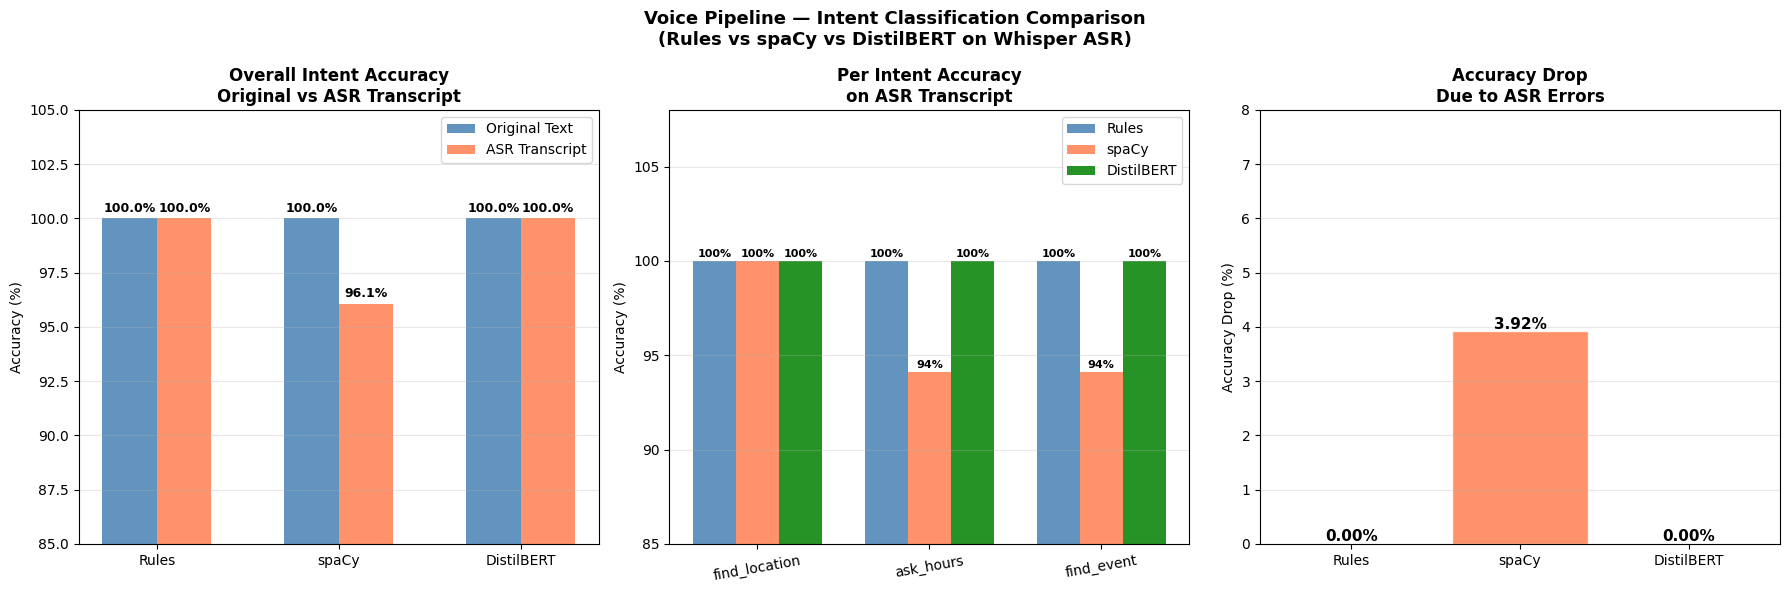

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Overall accuracy comparison ---
models     = ["Rules", "spaCy", "DistilBERT"]
orig_accs  = [100.0, 100.0, 100.0]
trans_accs = [100.0, 96.08, 100.0]

x     = np.arange(len(models))
width = 0.3

b1 = axes[0].bar(x - width/2, orig_accs,  width, label="Original Text", color="steelblue", alpha=0.85)
b2 = axes[0].bar(x + width/2, trans_accs, width, label="ASR Transcript", color="coral",    alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[0].set_title("Overall Intent Accuracy\nOriginal vs ASR Transcript", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(85, 105)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# --- Plot 2: Per intent accuracy on transcript ---
intents     = ["find_location", "ask_hours", "find_event"]
rules_trans = [100.0, 100.0, 100.0]
spacy_trans = [100.0, 94.12, 94.12]
db_trans    = [100.0, 100.0, 100.0]

x     = np.arange(len(intents))
width = 0.25

b1 = axes[1].bar(x - width, rules_trans, width, label="Rules",      color="steelblue", alpha=0.85)
b2 = axes[1].bar(x,          spacy_trans, width, label="spaCy",      color="coral",     alpha=0.85)
b3 = axes[1].bar(x + width,  db_trans,    width, label="DistilBERT", color="green",     alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                     f'{h:.0f}%', ha='center', fontsize=8, fontweight='bold')

axes[1].set_title("Per Intent Accuracy\non ASR Transcript", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(intents, rotation=10)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(85, 108)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# --- Plot 3: Accuracy drop due to ASR ---
acc_drops = [0.0, 3.92, 0.0]
colors    = ["steelblue", "coral", "green"]

bars = axes[2].bar(models, acc_drops, color=colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, acc_drops):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

axes[2].set_title("Accuracy Drop\nDue to ASR Errors", fontweight="bold")
axes[2].set_ylabel("Accuracy Drop (%)")
axes[2].set_ylim(0, 8)
axes[2].grid(axis="y", alpha=0.3)
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle("Voice Pipeline — Intent Classification Comparison\n(Rules vs spaCy vs DistilBERT on Whisper ASR)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("voice_intent_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

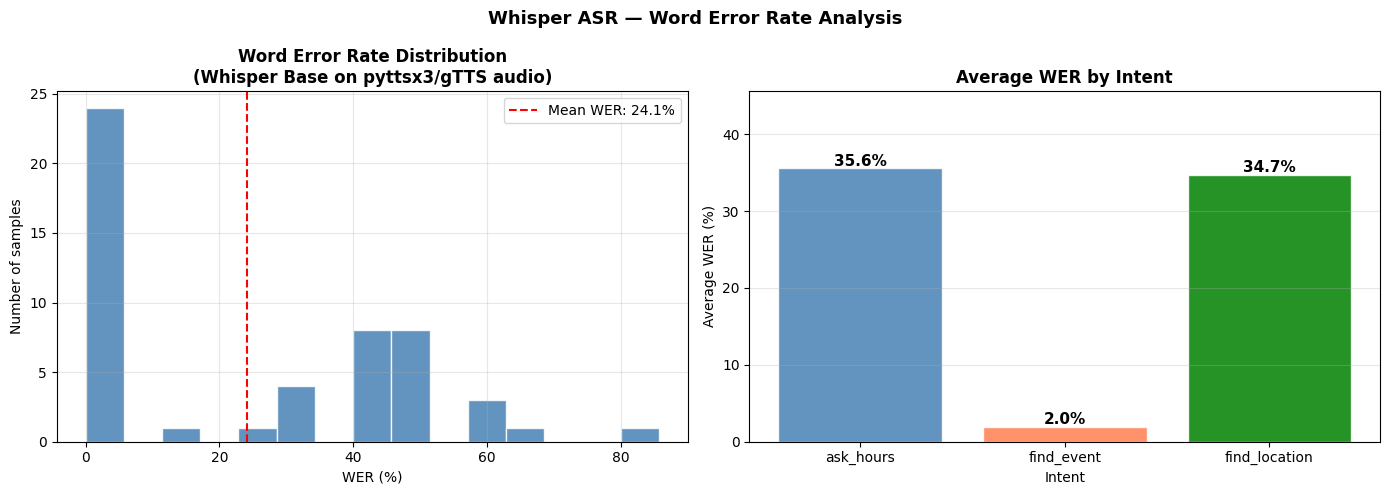

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: WER distribution histogram ---
wer_pct = df_results["wer"] * 100
axes[0].hist(wer_pct, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(x=wer_pct.mean(), color="red", linestyle="--",
                label=f"Mean WER: {wer_pct.mean():.1f}%")
axes[0].set_title("Word Error Rate Distribution\n(Whisper Base on pyttsx3/gTTS audio)", fontweight="bold")
axes[0].set_xlabel("WER (%)")
axes[0].set_ylabel("Number of samples")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: WER per intent ---
wer_by_intent = df_results.groupby("expected")["wer"].mean() * 100
axes[1].bar(wer_by_intent.index, wer_by_intent.values,
            color=["steelblue", "coral", "green"], alpha=0.85, edgecolor="white")
for i, (intent, val) in enumerate(wer_by_intent.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center',
                 fontsize=11, fontweight='bold')
axes[1].set_title("Average WER by Intent", fontweight="bold")
axes[1].set_xlabel("Intent")
axes[1].set_ylabel("Average WER (%)")
axes[1].set_ylim(0, wer_by_intent.max() + 10)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Whisper ASR — Word Error Rate Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("voice_wer_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
print("=" * 55)
print("   Voice Pipeline Summary")
print("=" * 55)
print(f"  TTS engine          : gTTS")
print(f"  ASR model           : Whisper base")
print(f"  Total samples       : {len(df_results)}")
print(f"  Average WER         : {df_results['wer'].mean()*100:.1f}%")
print(f"  Exact match rate    : {(df_results['wer']==0).sum()/len(df_results)*100:.1f}%")
print()
print(f"  Intent Accuracy on Original Text:")
print(f"    Rules      : 100.0%")
print(f"    spaCy      : 100.0%")
print(f"    DistilBERT : 100.0%")
print()
print(f"  Intent Accuracy on ASR Transcript:")
print(f"    Rules      : {df_results['rules_trans_correct'].mean()*100:.1f}%")
print(f"    spaCy      : {df_results['spacy_trans_correct'].mean()*100:.1f}%")
print(f"    DistilBERT : {df_results['db_trans_correct'].mean()*100:.1f}%")
print()
print(f"  Accuracy drop due to ASR:")
print(f"    Rules      : {100 - df_results['rules_trans_correct'].mean()*100:.1f}%")
print(f"    spaCy      : {100 - df_results['spacy_trans_correct'].mean()*100:.1f}%")
print(f"    DistilBERT : {100 - df_results['db_trans_correct'].mean()*100:.1f}%")
print()
print(f"  Best model for voice : Rules + DistilBERT (tied)")
print(f"  Key insight          : High WER on lab codes does")
print(f"                         not affect intent accuracy")
print("=" * 55)

   Voice Pipeline Summary
  TTS engine          : gTTS
  ASR model           : Whisper base
  Total samples       : 51
  Average WER         : 24.1%
  Exact match rate    : 47.1%

  Intent Accuracy on Original Text:
    Rules      : 100.0%
    spaCy      : 100.0%
    DistilBERT : 100.0%

  Intent Accuracy on ASR Transcript:
    Rules      : 100.0%
    spaCy      : 96.1%
    DistilBERT : 100.0%

  Accuracy drop due to ASR:
    Rules      : 0.0%
    spaCy      : 3.9%
    DistilBERT : 0.0%

  Best model for voice : Rules + DistilBERT (tied)
  Key insight          : High WER on lab codes does
                         not affect intent accuracy
